<a href="https://colab.research.google.com/github/almendraapolaya/DI_Bootcamp_a/blob/main/Week_5/Day_1/Daily_challenge/Daily_challenge.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Daily Challenge: Logistic Regression for Admission Prediction
===

You will create a logistic regression model that uses examination scores to predict university admission.
dataset available here


**Your Task**

Data Exploration: Load and visualize the data.

- Use pandas to load the dataset and examine the first few rows.
- Create a scatter plot to visualize the data points for students who were admitted versus those who were not based on their exam scores.

Applying Logistic Regression with scikit-learn:

- Implement logistic regression using the LogisticRegression function from scikit-learn to find the best parameters for your model.
- Train the logistic regression model on your dataset.

Making Predictions:

- Use the trained logistic regression model to make predictions on your dataset.
- Calculate the accuracy of your model.

Model Evaluation:

- Interpret the result of logistic regression and the accuracy of your model.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

#Loading the dataset:

columns = ['Exam_1', 'Exam_2', 'Admitted']
df = pd.read_csv('ex2data1.txt', header=None, names=columns)

print(df.head())

      Exam_1     Exam_2  Admitted
0  34.623660  78.024693         0
1  30.286711  43.894998         0
2  35.847409  72.902198         0
3  60.182599  86.308552         1
4  79.032736  75.344376         1


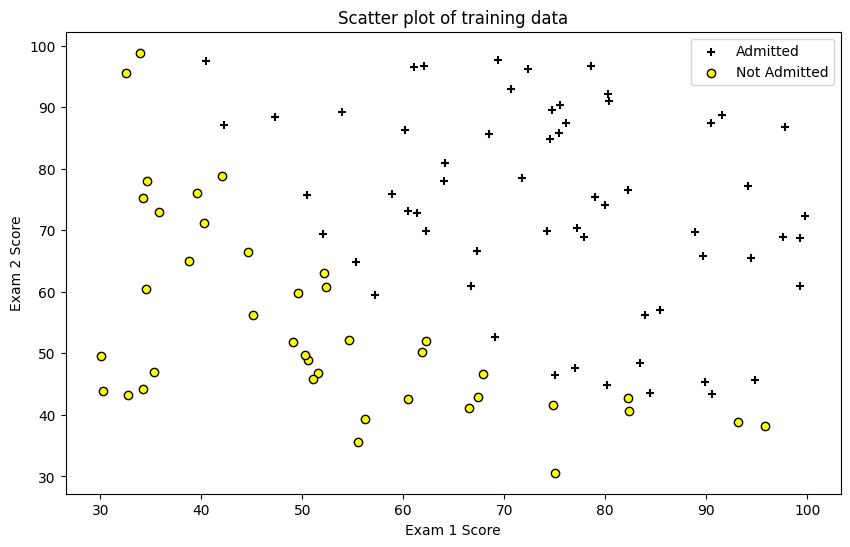

In [ ]:
#scatter plot
admitted = df[df['Admitted'] == 1]
not_admitted = df[df['Admitted'] == 0]

plt.figure(figsize=(10, 6))

plt.scatter(admitted['Exam_1'], admitted['Exam_2'], marker='+', color='black', label='Admitted')

plt.scatter(not_admitted['Exam_1'], not_admitted['Exam_2'], marker='o', color='yellow', edgecolor='black', label='Not Admitted')

plt.xlabel('Exam 1 Score')
plt.ylabel('Exam 2 Score')
plt.legend()
plt.title('Scatter plot of training data')
plt.show()

In [ ]:
#Logistic Regression:

from sklearn.linear_model import LogisticRegression
import numpy as np

X = df[['Exam_1', 'Exam_2']]

y = df['Admitted']

model = LogisticRegression()

model.fit(X, y)

print(f"Intercept (theta 0): {model.intercept_}")
print(f"Coefficients (theta 1, theta 2): {model.coef_}")

Intercept (theta 0): [-25.05219314]
Coefficients (theta 1, theta 2): [[0.20535491 0.2005838 ]]


In [ ]:
#Making predictions:

y_pred = model.predict(X)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, y_pred)

print(f"Model Predictions: {y_pred[:10]}")
print(f"Accuracy: {accuracy * 100:.2f}%")

Model Predictions: [0 0 0 1 1 0 1 0 1 1]
Accuracy: 89.00%


In [ ]:
#Model Evaluation:

print(f"Final Accuracy: {accuracy * 100:.2f}%")

#Checking a specific prediction
sample_student = np.array([[45, 85]])
prediction = model.predict(sample_student)
probability = model.predict_proba(sample_student)

print(f"Prediction for scores (45, 85): {'Admitted' if prediction[0] == 1 else 'Not Admitted'}")
print(f"Probability of Admission: {probability[0][1] * 100:.2f}%")

Final Accuracy: 89.00%
Prediction for scores (45, 85): Admitted
Probability of Admission: 77.53%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


**Conclusion:**

After watching the results I got from this machine learning model, I have learned from this data that university admission is not random but follows a clear mathematical pattern where higher scores in both exams significantly increase the probability of success. By visualizing the data and training a Logistic Regression model, I identified a Decision Boundary, a specific line that separates students into two categories with approximately 89% accuracy. This insight proves that while Exam 1 and Exam 2 are the primary drivers for admission, the small error rate suggests that a linear model cannot perfectly account for every outlier, likely because the admissions process involves subtle nuances or additional variables not present in this dataset. Finally, this exercise shows that we can move beyond simple observation to build a system that not only predicts outcomes but also provides a specific probability of certainty for each student’s future.